In [15]:
import os
import torch
import matplotlib.pyplot as plt
import pytorch_lightning as pl
from torch.optim import lr_scheduler
import segmentation_models_pytorch as smp
from torch.utils.data import DataLoader

from google.colab import drive
import os

# 挂载谷歌云盘
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -U git+https://github.com/qubvel-org/segmentation_models.pytorch
!pip install lightning albumentations

  Cloning https://github.com/qubvel-org/segmentation_models.pytorch to /tmp/pip-req-build-eqid3qtw
  Running command git clone --filter=blob:none --quiet https://github.com/qubvel-org/segmentation_models.pytorch /tmp/pip-req-build-eqid3qtw
  Resolved https://github.com/qubvel-org/segmentation_models.pytorch to commit 0dee83dc0e159cc11ff77d75e8732e253470f308
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for segmentation_models_pytorch: filename=segmentation_models_pytorch-0.5.1.dev0-py3-none-any.whl size=157855 sha256=cb5ef3c16dc0ef42add2010195a13a635925d17bec503c8331dc0b4881ab078e
  Stored in directory: /tmp/pip-ephem-wheel-cache-5ste0gxb/wheels/ff/bf/14/8c7545a42be4e75c5f7d9366c1f7a1917eed2e66fbd193a62e
Successfully built segmentation_models_pytorch
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.

In [16]:
root_path="/content/drive/MyDrive/myORFD/Final_Dataset"
train_img_dir = os.path.join(root_path,"training","image_data")
train_mask_dir = os.path.join(root_path,"training","gt_image")
val_img_dir = os.path.join(root_path,"validation", "image_data")
val_mask_dir = os.path.join(root_path,"validation","gt_image")
test_img_dir = os.path.join(root_path,"testing","image_data")
test_mask_dir = os.path.join(root_path,"testing","gt_image")
print("训练图片路径：", train_img_dir)
print("训练掩码路径：", train_mask_dir)
print("验证图片路径：", val_img_dir)
print("验证掩码路径：", val_mask_dir)

train_img_dir = os.path.join(root_path,"training","image_data")
train_mask_dir = os.path.join(root_path,"training","gt_image")
val_img_dir = os.path.join(root_path,"validation", "image_data")
val_mask_dir = os.path.join(root_path,"validation","gt_image")
test_img_dir = os.path.join(root_path,"testing","image_data")
test_mask_dir = os.path.join(root_path,"testing","gt_image")

count_train_img = len(os.listdir(train_img_dir))
count_train_mask = len(os.listdir(train_mask_dir))
count_val_img = len(os.listdir(val_img_dir))
count_val_mask = len(os.listdir(val_mask_dir))
count_test_img = len(os.listdir(test_img_dir))
count_test_mask = len(os.listdir(test_mask_dir))
print("===== 数据集数量统计 =====")
print(f"训练集原图数量：{count_train_img}")
print(f"训练集掩码数量：{count_train_mask}")
print(f"验证集原图数量：{count_val_img}")
print(f"验证集掩码数量：{count_val_mask}")
print(f"测试集原图数量：{count_test_img}")
print(f"测试集掩码数量：{count_test_mask}")

训练图片路径： /content/drive/MyDrive/myORFD/Final_Dataset/training/image_data
训练掩码路径： /content/drive/MyDrive/myORFD/Final_Dataset/training/gt_image
验证图片路径： /content/drive/MyDrive/myORFD/Final_Dataset/validation/image_data
验证掩码路径： /content/drive/MyDrive/myORFD/Final_Dataset/validation/gt_image
===== 数据集数量统计 =====
训练集原图数量：8392
训练集掩码数量：8392
验证集原图数量：1245
验证集掩码数量：1245
测试集原图数量：2193
测试集掩码数量：2193


In [ ]:
n_cpu = os.cpu_count()
train_dataloader = DataLoader(
    train_img_dir, batch_size=64, shuffle=True, num_workers=n_cpu
)
valid_dataloader = DataLoader(
    val_img_dir, batch_size=64, shuffle=False, num_workers=n_cpu
)
test_dataloader = DataLoader(
    test_img_dir, batch_size=64, shuffle=False, num_workers=n_cpu
)


In [17]:

import os
import cv2
import torch
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import numpy as np
# 自定义分割数据集类
class SegDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        # 获取所有原图文件名
        self.img_names = sorted([f for f in os.listdir(img_dir)
                                 if f.endswith((".jpg", ".png", ".jpeg"))])

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # 提取纯文件名，mask统一png
        file_stem = os.path.splitext(img_name)[0]
        mask_name = f"{file_stem}_fillcolor.png"
        mask_path = os.path.join(self.mask_dir, mask_name)

        # 读图
        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = np.array(image, dtype=np.float32)/255
        mask = np.array(mask, dtype=np.float32)/255

        return {
            "image": image,
            "mask": mask,
            "stem": file_stem
        }
# 你的全局路径
import torch
import torchvision.transforms as T

TARGET_SIZE = (320, 640)

def seg_collate_fn(batch):
    img_list = []
    mask_list = []
    for item in batch:
        img_np = item["image"]
        mask_np = item["mask"]

        # HWC numpy 转 CHW tensor
        img_tensor = torch.from_numpy(img_np).permute(2, 0, 1)
        mask_tensor = torch.from_numpy(mask_np).unsqueeze(0) # [1,H,W]

        # 统一缩放
        img_resize = T.Resize(TARGET_SIZE)(img_tensor)
        mask_resize = T.Resize(TARGET_SIZE, interpolation=T.InterpolationMode.NEAREST)(mask_tensor)

        img_list.append(img_resize)
        mask_list.append(mask_resize)

    return {
        "image": torch.stack(img_list),
        "mask": torch.stack(mask_list)
    }

root_path="/content/drive/MyDrive/myORFD/Final_Dataset"
train_img_dir = os.path.join(root_path,"training","image_data")
train_mask_dir = os.path.join(root_path,"training","gt_image")

train_ds = SegDataset(train_img_dir, train_mask_dir)
val_ds = SegDataset(val_img_dir, val_mask_dir)
test_ds = SegDataset(test_img_dir, test_mask_dir)

BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=seg_collate_fn

)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=seg_collate_fn

)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=seg_collate_fn

)

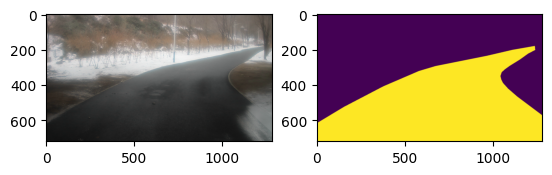

In [18]:
sample = train_ds[0]
plt.subplot(1, 2, 1)
plt.imshow(sample["image"])
plt.subplot(1, 2, 2)
plt.imshow(sample["mask"].squeeze())
plt.show()

In [ ]:
sample

In [23]:
EPOCHS = 10
T_MAX = EPOCHS * len(train_loader)
OUT_CLASSES = 3

class PathModel(pl.LightningModule):
    def __init__(self, arch, encoder_name, in_channels, out_classes, **kwargs):
        super().__init__()
        self.model = smp.create_model(
            arch,
            encoder_name=encoder_name,
            in_channels=in_channels,
            classes=out_classes,
            **kwargs,
        )
        # preprocessing parameteres for image
        params = smp.encoders.get_preprocessing_params(encoder_name)
        self.register_buffer("std", torch.tensor(params["std"]).view(1, 3, 1, 1))
        self.register_buffer("mean", torch.tensor(params["mean"]).view(1, 3, 1, 1))

        # for image segmentation dice loss could be the best first choice
        self.loss_fn = smp.losses.DiceLoss(smp.losses.MULTICLASS_MODE, from_logits=True)

        # initialize step metics
        self.training_step_outputs = []
        self.validation_step_outputs = []
        self.test_step_outputs = []

    def forward(self, image):
        # normalize image here
        image = (image - self.mean) / self.std
        mask = self.model(image)
        return mask

    def shared_step(self, batch, stage):
        image = batch["image"]
        assert image.ndim == 4

        h, w = image.shape[2:]
        assert h % 32 == 0 and w % 32 == 0

        mask = batch["mask"]
        assert mask.ndim == 4

        # ========== 二分类mask范围断言 ==========
        # assert mask.max() <= 1.0 and mask.min() >= 0

        logits_mask = self.forward(image)

        # 取出 \[B,1,H,W\] → \[B,H,W\] 浮点图
        mask_float = mask.squeeze(1)
        # 新建整数标签容器
        mask_gt = torch.zeros_like(mask_float, dtype=torch.long)

        # 区间映射：0=背景，1=天空，2=道路
        mask_gt[mask_float < 0.2] = 0
        mask_gt[(mask_float >= 0.2) & (mask_float < 0.8)] = 1
        mask_gt[mask_float >= 0.8] = 2

        loss = self.loss_fn(logits_mask, mask_gt)

        # ========== 二分类sigmoid阈值预测，多分类argmax ==========
        # prob_mask = logits_mask.sigmoid()
        # pred_mask = (prob_mask > 0.5).float()
        pred_mask = torch.argmax(logits_mask, dim=1)  # [B,3,H,W] -> [B,H,W]
        tp, fp, fn, tn = smp.metrics.get_stats(
            pred_mask.long(),
            mask_gt,
            mode="multiclass",
            num_classes=OUT_CLASSES
        )
        return {
            "loss": loss,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
        }


    def shared_epoch_end(self, outputs, stage):
        # aggregate step metics
        tp = torch.cat([x["tp"] for x in outputs])
        fp = torch.cat([x["fp"] for x in outputs])
        fn = torch.cat([x["fn"] for x in outputs])
        tn = torch.cat([x["tn"] for x in outputs])

        # per image IoU means that we first calculate IoU score for each image
        # and then compute mean over these scores
        per_image_iou = smp.metrics.iou_score(
            tp, fp, fn, tn, reduction="micro-imagewise"
        )

        # dataset IoU means that we aggregate intersection and union over whole dataset
        # and then compute IoU score. The difference between dataset_iou and per_image_iou scores
        # in this particular case will not be much, however for dataset
        # with "empty" images (images without target class) a large gap could be observed.
        # Empty images influence a lot on per_image_iou and much less on dataset_iou.
        dataset_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")
        metrics = {
            f"{stage}_per_image_iou": per_image_iou,
            f"{stage}_dataset_iou": dataset_iou,
        }

        self.log_dict(metrics, prog_bar=True)

    def training_step(self, batch, batch_idx):
        train_loss_info = self.shared_step(batch, "train")
        # append the metics of each step to the
        self.training_step_outputs.append(train_loss_info)
        return train_loss_info

    def on_train_epoch_end(self):
        self.shared_epoch_end(self.training_step_outputs, "train")
        # empty set output list
        self.training_step_outputs.clear()
        return

    def validation_step(self, batch, batch_idx):
        valid_loss_info = self.shared_step(batch, "valid")
        self.validation_step_outputs.append(valid_loss_info)
        return valid_loss_info

    def on_validation_epoch_end(self):
        self.shared_epoch_end(self.validation_step_outputs, "valid")
        self.validation_step_outputs.clear()
        return

    def test_step(self, batch, batch_idx):
        test_loss_info = self.shared_step(batch, "test")
        self.test_step_outputs.append(test_loss_info)
        return test_loss_info

    def on_test_epoch_end(self):
        self.shared_epoch_end(self.test_step_outputs, "test")
        # empty set output list
        self.test_step_outputs.clear()
        return

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=2e-4)
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_MAX, eta_min=1e-5)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",
                "frequency": 1,
            },
        }
        return

model = PathModel("linknet", "resnet18", in_channels=3, out_classes=OUT_CLASSES)



In [ ]:
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint

checkpoint_callback = ModelCheckpoint(
    every_n_epochs=1,
    save_top_k=-1,
    dirpath="/content/drive/MyDrive/model_checkpoints",  # 存网盘
    filename="model-epoch-{epoch:02d}",
    monitor=None,
)
trainer = pl.Trainer(
    max_epochs=EPOCHS,
    log_every_n_steps=10,
    accelerator="gpu",
    devices=1,
    precision="16-mixed",
    callbacks=[checkpoint_callback] # 加入保存回调
)

trainer.fit(
    model,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type     ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model   │ Linknet  │ 11.7 M │ train │     0 │
│ 1 │ loss_fn │ DiceLoss │      0 │ train │     0 │
└───┴─────────┴──────────┴────────┴───────┴───────┘

Trainable params: 11.7 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.7 M                                                                                               
Total estimated model params size (MB): 46.655                                                                     
Modules in train mode: 145                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

In [ ]:
# 完整保存训练全部状态（权重+优化器+epoch+学习率，支持断点续训）
import torch

full_ckpt_path = "/content/drive/MyDrive/seg_full_last.ckpt"
trainer.save_checkpoint(full_ckpt_path)
print(f"完整模型断点已保存至：{full_ckpt_path}")


In [ ]:
import glob
files = glob.glob("./checkpoints/*.ckpt")
for f in files:
    print(f"文件路径：{f}，大小：{os.path.getsize(f)/1024/1024:.2f} MB")




文件路径：./checkpoints/model-epoch-epoch=00.ckpt，大小：133.70 MB
文件路径：./checkpoints/model-epoch-epoch=05.ckpt，大小：133.70 MB
文件路径：./checkpoints/model-epoch-epoch=01.ckpt，大小：133.70 MB
文件路径：./checkpoints/model-epoch-epoch=02.ckpt，大小：133.70 MB
文件路径：./checkpoints/model-epoch-epoch=04.ckpt，大小：133.70 MB
文件路径：./checkpoints/model-epoch-epoch=03.ckpt，大小：133.70 MB


In [ ]:
a=1
